전처리 과정 생략
자치구 별 단계 구분도 시각화

c:\Users\DH\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


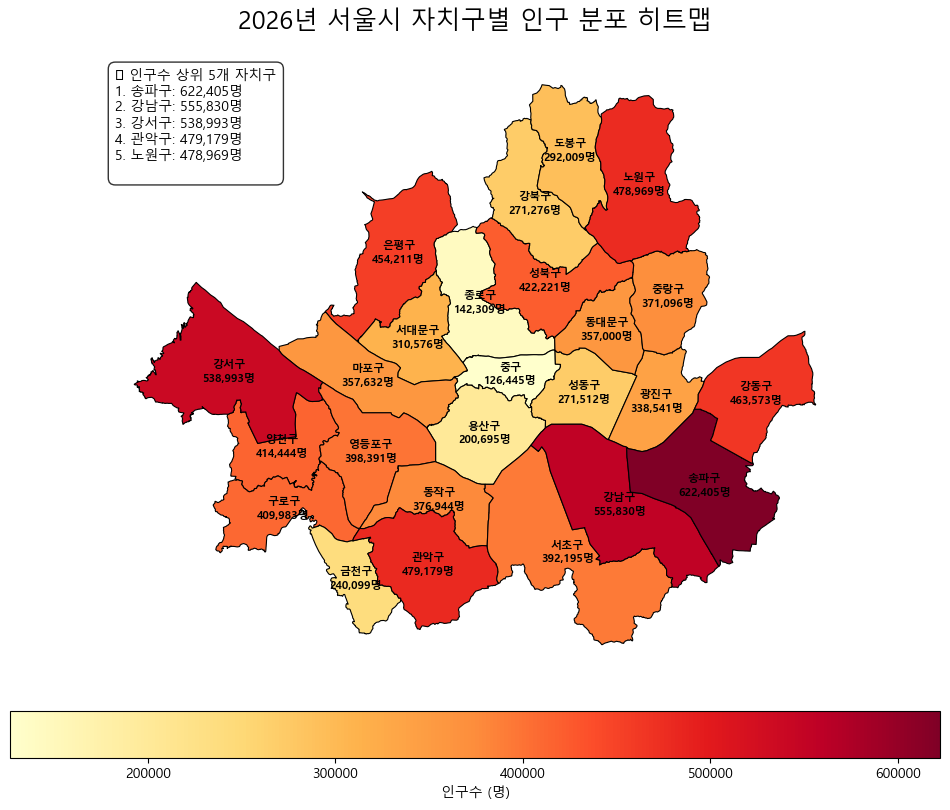

In [9]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from plt_style import set_korean

set_korean()


# ================================
# 1. 데이터 로드 함수
# ================================
def load_population_data(file_path):
    df = pd.read_csv(file_path, header=None)

    pop_df = df.iloc[4:, [1, 2]].copy()
    pop_df.columns = ['자치구', '인구수']
    pop_df['인구수'] = pd.to_numeric(pop_df['인구수'])

    return pop_df


def load_geo_data(geo_path):
    return gpd.read_file(geo_path)


# ================================
# 2. 데이터 결합
# ================================
def merge_data(geo_df, pop_df, geo_key='SIG_KOR_NM'):
    return geo_df.merge(pop_df, left_on=geo_key, right_on='자치구')


# ================================
# 3. Top N 텍스트 생성
# ================================
def make_topn_text(df, n=5):
    topn_df = df.sort_values(by='인구수', ascending=False).head(n)

    text = f"📊 인구수 상위 {n}개 자치구\n"
    for i, row in enumerate(topn_df.itertuples(), 1):
        text += f"{i}. {row.자치구}: {int(row.인구수):,}명\n"

    return text


# ================================
# 4. 시각화
# ================================
def plot_map(merged_df, topn_text):
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))

    # 지도
    merged_df.plot(
        column='인구수',
        cmap='YlOrRd',
        legend=True,
        edgecolor='black',
        linewidth=0.8,
        ax=ax,
        legend_kwds={
            'label': "인구수 (명)",
            'orientation': "horizontal",
            'pad': 0.05
        }
    )

    # 자치구 라벨
    for _, row in merged_df.iterrows():
        centroid = row.geometry.centroid
        label = f"{row['자치구']}\n{int(row['인구수']):,}명"

        ax.text(
            centroid.x, centroid.y, label,
            fontsize=8,
            ha='center',
            va='center',
            fontweight='bold',
            color='black'
        )

    # Top N 박스 (⚠️ 반복문 밖으로 이동)
    ax.text(
        0.02, 0.98, topn_text,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(
            facecolor='white',
            alpha=0.8,
            edgecolor='black',
            boxstyle='round,pad=0.5'
        )
    )

    plt.title('2026년 서울시 자치구별 인구 분포 히트맵', fontsize=18, pad=20)
    ax.axis('off')
    plt.show()


# ================================
# 5. 실행
# ================================
pop_df = load_population_data('data/자치구별+총인구(추계인구).csv')
geo_df = load_geo_data('polygon/서울시_자치구.geojson')

merged_df = merge_data(geo_df, pop_df)
top5_text = make_topn_text(merged_df, n=5)

plot_map(merged_df, top5_text)

+ 2021 ~~ 2024 신고 현황도

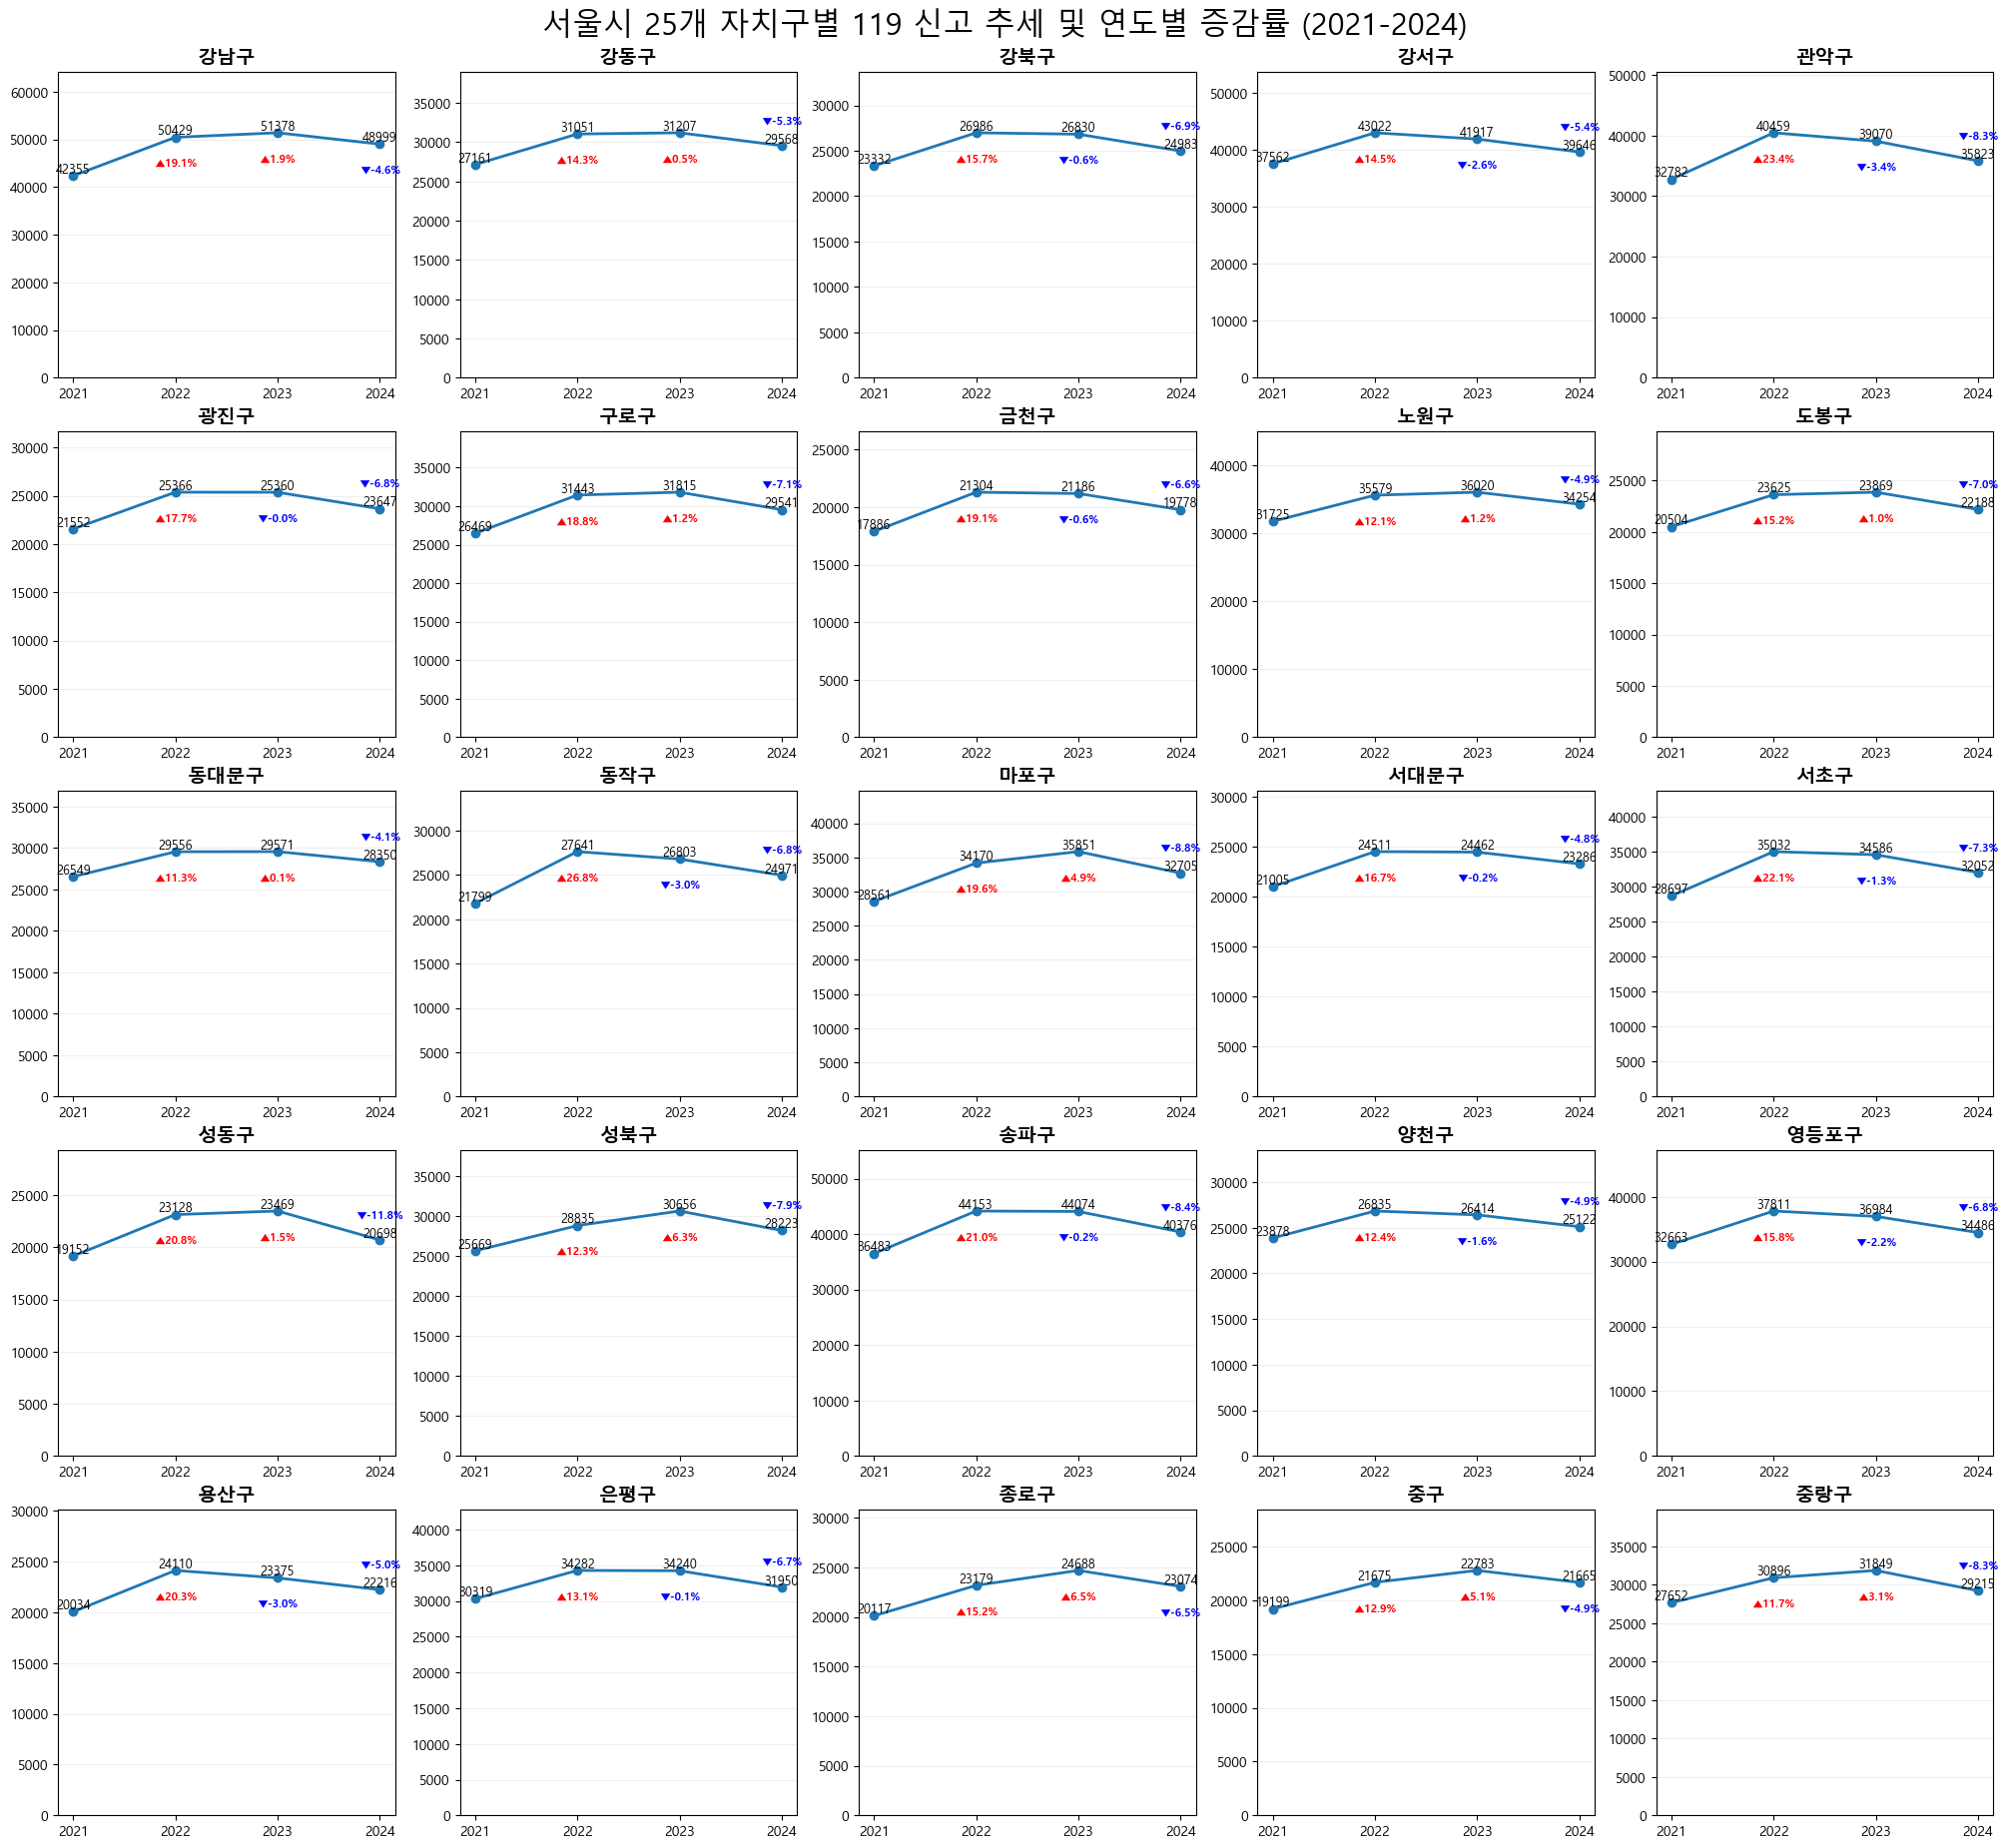

In [15]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from plt_style import set_korean

set_korean()


# ================================
# 1. 공통 함수
# ================================
def load_geo_data(path):
    return gpd.read_file(path).to_crs("EPSG:4326")


def preprocess_119_data(file_path):
    df = pd.read_csv(file_path, encoding='utf-8-sig')
    df.columns = df.columns.str.strip().str.upper()
    df = df.dropna(subset=['DAMG_RGN_LOT', 'DAMG_RGN_LAT']).copy()
    return df


def convert_to_gdf(df):
    return gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df['DAMG_RGN_LOT'], df['DAMG_RGN_LAT']),
        crs="EPSG:4326"
    )


def aggregate_by_gu(point_gdf, geo_df, gu_col):
    joined = gpd.sjoin(point_gdf, geo_df[[gu_col, 'geometry']],
                       predicate='within', how='inner')
    return joined.groupby(gu_col).size().reset_index(name='사고건수')


# ================================
# 2. 연도별 데이터 통합
# ================================
def build_trend_data(years, geo_df, gu_col):
    all_data = []

    for year in years:
        df = preprocess_119_data(f'data/119 신고접수 현황/신고접수_{year}.csv')
        gdf = convert_to_gdf(df)
        counts = aggregate_by_gu(gdf, geo_df, gu_col)

        counts['연도'] = year
        all_data.append(counts)

    return pd.concat(all_data)


# ================================
# 3. 시각화
# ================================
def plot_trend(df_trend, gu_col):
    fig, axes = plt.subplots(5, 5, figsize=(20, 18), constrained_layout=True)
    axes = axes.flatten()

    all_gu = sorted(df_trend[gu_col].unique())

    for i, gu in enumerate(all_gu):
        ax = axes[i]
        data = df_trend[df_trend[gu_col] == gu].sort_values('연도').copy()

        # 선 그래프
        ax.plot(data['연도'], data['사고건수'],
                marker='o', linewidth=2)

        ax.set_title(gu, fontsize=14, fontweight='bold')
        ax.set_xticks([2021, 2022, 2023, 2024])
        ax.grid(True, axis='y', alpha=0.2)

        # y축 여백 확보
        y_max = data['사고건수'].max()
        ax.set_ylim(0, y_max * 1.25)

        # 증감률 계산
        data['prev_count'] = data['사고건수'].shift(1)
        data['change_rate'] = ((data['사고건수'] - data['prev_count']) /
                               data['prev_count']) * 100

        offset = y_max * 0.08

        for _, row in data.iterrows():
            # 값 표시
            ax.text(row['연도'], row['사고건수'],
                    f"{int(row['사고건수'])}",
                    ha='center', va='bottom', fontsize=9)

            # 증감률 표시
            if not pd.isna(row['change_rate']):
                color = 'red' if row['change_rate'] > 0 else 'blue'
                symbol = '▲' if row['change_rate'] > 0 else '▼'

                # 🔥 위치 자동 조정
                if row['사고건수'] < data['사고건수'].mean():
                    y_pos = row['사고건수'] + offset
                    va = 'bottom'
                else:
                    y_pos = row['사고건수'] - offset
                    va = 'top'

                ax.text(
                    row['연도'],
                    y_pos,
                    f"{symbol}{row['change_rate']:.1f}%",
                    ha='center',
                    va=va,
                    fontsize=8,
                    color=color,
                    fontweight='bold'
                )

    # 남는 subplot 제거
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(
        '서울시 25개 자치구별 119 신고 추세 및 연도별 증감률 (2021-2024)',
        fontsize=22, y=1.02
    )

    plt.show()


# ================================
# 4. 실행
# ================================
geo_df = load_geo_data('polygon/서울시_자치구.geojson')
gu_col = 'SIG_KOR_NM'

df_trend = build_trend_data(
    [2021, 2022, 2023, 2024],
    geo_df,
    gu_col
)

plot_trend(df_trend, gu_col)

자치구 단위 차원 통합 및 RBI 산출 파트

In [ ]:
# --- 1. 안전센터 데이터 로드 및 처리 ---
df_center_raw = pd.read_csv('data/시내주요기관 수.csv', header=None)
center_df = df_center_raw.iloc[3:, [1, 2]].copy()
center_df.columns = ['자치구', '안전센터수']
center_df = center_df[center_df['자치구'] != '기타']
center_df['안전센터수'] = center_df['안전센터수'].astype(int)

# --- 2. 출동건수 데이터 로드 및 처리 ---
df_dispatch_raw = pd.read_csv('data/119 구조활동 실적(구별).csv', header=None)
dispatch_df = df_dispatch_raw.iloc[5:, [1, 2]].copy()
dispatch_df.columns = ['자치구', '출동건수']
dispatch_df = dispatch_df[dispatch_df['자치구'] != '기타']
dispatch_df['출동건수'] = pd.to_numeric(dispatch_df['출동건수'], errors='coerce')
dispatch_df = dispatch_df.dropna(subset=['출동건수'])
dispatch_df['출동건수'] = dispatch_df['출동건수'].astype(int)

# --- 3. 화재사고 데이터 집계 ---
df_fire_raw = pd.read_csv('data/화재사고 구조출동 현황/화재사고_2024.csv', encoding='utf-8-sig')
fire_counts = df_fire_raw['GRNDS_SGG_NM'].value_counts().reset_index()
fire_counts.columns = ['자치구', '화재사고건수']

# --- 4. 교통사고 데이터 집계 ---
df_traffic_raw = pd.read_csv('data/교통사고 구조출동 현황/교통사고_2024.csv', encoding='utf-8-sig')
traffic_counts = df_traffic_raw['GRNDS_SGG_NM'].value_counts().reset_index()
traffic_counts.columns = ['자치구', '교통사고건수']

# --- 5. 통합 데이터셋(risk_data) 구축 (모든 원천 컬럼 보존) ---
# 1) 인구 데이터 기반 시작
risk_data = pop_df.copy() # 자치구, 인구수 포함

# 2) 순차적 병합 (how='left'를 권장합니다. 혹시라도 데이터가 누락된 구가 있으면 NaN으로 파악하기 위함)
risk_data = pd.merge(risk_data, center_df, on='자치구', how='left')      # + 안전센터수
risk_data = pd.merge(risk_data, dispatch_df, on='자치구', how='left')    # + 출동건수
risk_data = pd.merge(risk_data, fire_counts, on='자치구', how='left')    # + 화재사고건수
risk_data = pd.merge(risk_data, traffic_counts, on='자치구', how='left') # + 교통사고건수

# 3) 결측치 및 데이터 타입 정제
# 사고가 발생하지 않아 데이터가 없는 구는 0으로 채우고 정수형으로 변환
cols_to_fix = ['안전센터수', '출동건수', '화재사고건수', '교통사고건수']
risk_data[cols_to_fix] = risk_data[cols_to_fix].fillna(0).astype(int)

# --- 6. 지표(Index) 컬럼 추가 (원천 데이터는 그대로 유지됨) ---

# [지표 1] 공급-수요 비율 (센터 1곳당 부담량)
risk_data['센터당_인구'] = risk_data['인구수'] / risk_data['안전센터수']
risk_data['센터당_화재'] = risk_data['화재사고건수'] / risk_data['안전센터수']
risk_data['센터당_출동'] = risk_data['출동건수'] / risk_data['안전센터수']

# [지표 2] 인구 대비 발생률 (인구 10만 명당 건수)
risk_data['인구10만당_화재'] = (risk_data['화재사고건수'] / risk_data['인구수']) * 100000
risk_data['인구10만당_출동'] = (risk_data['출동건수'] / risk_data['인구수']) * 100000
risk_data['인구10만당_교통'] = (risk_data['교통사고건수'] / risk_data['인구수']) * 100000

# [지표 3] LQ (입지계수: 서울 전체 평균 대비 해당 구의 집중도)
total_pop = risk_data['인구수'].sum()
total_fire = risk_data['화재사고건수'].sum()
total_rescue = risk_data['출동건수'].sum()

risk_data['LQ_화재'] = (risk_data['화재사고건수'] / total_fire) / (risk_data['인구수'] / total_pop)
risk_data['LQ_구조'] = (risk_data['출동건수'] / total_rescue) / (risk_data['인구수'] / total_pop)

print("✅ 모든 원천 데이터 및 지표가 통합 완료")
print(risk_data.head())

✅ 모든 원천 데이터 및 지표가 통합되었습니다.
   자치구     인구수  안전센터수  출동건수  화재사고건수  교통사고건수         센터당_인구      센터당_화재  \
0  종로구  142309      6  6291    1639     219   23718.166667  273.166667   
1   중구  126445      5  4455    1319     149   25289.000000  263.800000   
2  용산구  200695      5  6849    1415     336   40139.000000  283.000000   
3  성동구  271512      4  4903    1454     285   67878.000000  363.500000   
4  광진구  338541      3  6983    1815     267  112847.000000  605.000000   

        센터당_출동    인구10만당_화재    인구10만당_출동   인구10만당_교통     LQ_화재     LQ_구조  
0  1048.500000  1151.719146  4420.662080  153.890478  1.863907  1.933680  
1   891.000000  1043.141287  3523.270987  117.837795  1.688188  1.541144  
2  1369.800000   705.049951  3412.641072  167.418222  1.141031  1.492753  
3  1225.750000   535.519609  1805.813371  104.967736  0.866669  0.789896  
4  2327.666667   536.124133  2062.674831   78.867848  0.867647  0.902252  


In [18]:
risk_data.to_csv('output/자치구 단위 RBI.csv', index=False)